In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [14]:
# 1. Load data
df = pd.read_csv('https://raw.githubusercontent.com/baren-kumar/ML-Material-Science-/refs/heads/main/carbon_fiber_epoxy_composite_dataset.csv')

In [15]:
df.head()

,carbon_fiber_fraction,epoxy_resin_fraction,volume_fraction,strength_MPa,stiffness_GPa,toughness_MJ_per_m3
0,0.449816,0.550184,0.559449,1156.999990,107.023571,11.055131
1,0.680286,0.319714,0.510829,1378.448318,131.305094,9.663145
2,0.592798,0.407202,0.442858,1311.334685,122.390584,9.196823
3,0.539463,0.460537,0.594139,1284.501346,123.284659,11.995826
4,0.362407,0.637593,0.555419,1062.766531,91.775722,13.108135


In [16]:
df.isnull().sum()

,0
carbon_fiber_fraction,0
epoxy_resin_fraction,0
volume_fraction,0
strength_MPa,0
stiffness_GPa,0
toughness_MJ_per_m3,0


In [17]:
# 2. Define Features and Target
X = df[['carbon_fiber_fraction', 'epoxy_resin_fraction', 'volume_fraction']]
y = df['strength_MPa']

In [19]:
# 3. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# 4. Initialize and Train Models
# Linear Kernel
linear_svr = SVR(kernel='linear')
linear_svr.fit(X_train_scaled, y_train)

# RBF Kernel (with optimized hyperparameters)
rbf_svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
rbf_svr.fit(X_train_scaled, y_train)

SVR(C=100, gamma=0.1)

In [21]:
# 5. Evaluate
y_pred_linear = linear_svr.predict(X_test_scaled)
y_pred_rbf = rbf_svr.predict(X_test_scaled)

# Calculate R2 Score
r2_linear = r2_score(y_test, y_pred_linear)
r2_rbf = r2_score(y_test, y_pred_rbf)

# Calculate Mean Squared Error (MSE)
mse_linear = mean_squared_error(y_test, y_pred_linear)
mse_rbf = mean_squared_error(y_test, y_pred_rbf)

# Calculate Root Mean Squared Error (RMSE)
rmse_linear = np.sqrt(mse_linear)
rmse_rbf = np.sqrt(mse_rbf)

print("--- Linear SVR Model Evaluation ---")
print(f"R2 Score: {r2_linear:.4f}")
print(f"MSE: {mse_linear:.2f}")
print(f"RMSE: {rmse_linear:.2f}")
print("\n--- RBF SVR Model Evaluation ---")
print(f"R2 Score: {r2_rbf:.4f}")
print(f"MSE: {mse_rbf:.2f}")
print(f"RMSE: {rmse_rbf:.2f}")

--- Linear SVR Model Evaluation ---
R2 Score: 0.9496
MSE: 1053.54
RMSE: 32.46

--- RBF SVR Model Evaluation ---
R2 Score: 0.9503
MSE: 1039.49
RMSE: 32.24


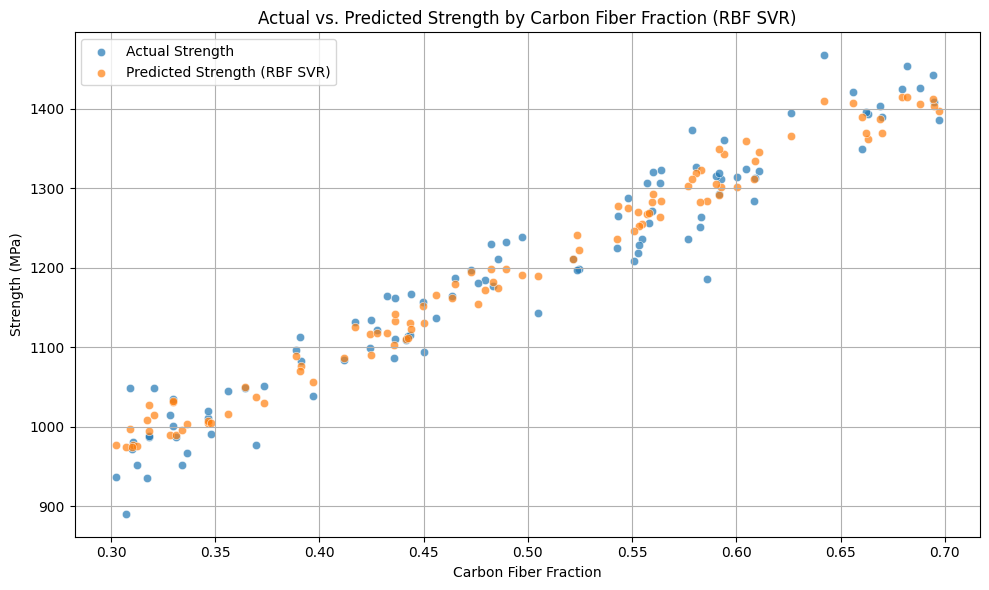

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure y_pred_rbf is available
if 'y_pred_rbf' not in locals():
    y_pred_rbf = rbf_svr.predict(X_test_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['carbon_fiber_fraction'], y=y_test, label='Actual Strength', alpha=0.7)
sns.scatterplot(x=X_test['carbon_fiber_fraction'], y=y_pred_rbf, label='Predicted Strength (RBF SVR)', alpha=0.7)
plt.xlabel('Carbon Fiber Fraction')
plt.ylabel('Strength (MPa)')
plt.title('Actual vs. Predicted Strength by Carbon Fiber Fraction (RBF SVR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
def predict_strength(carbon_fiber_fraction, epoxy_resin_fraction, volume_fraction):
    # Create a DataFrame for the new input
    new_data = pd.DataFrame({
        'carbon_fiber_fraction': [carbon_fiber_fraction],
        'epoxy_resin_fraction': [epoxy_resin_fraction],
        'volume_fraction': [volume_fraction]
    })

    # Scale the new input data using the same scaler fitted on the training data
    new_data_scaled = scaler.transform(new_data)

    # Predict the strength using the RBF SVR model
    predicted_strength = rbf_svr.predict(new_data_scaled)
    return predicted_strength[0]

# Example usage:
carbon_fiber_fraction = 0.60
epoxy_resin_fraction = 0.40
volume_fraction = 0.58

predicted_val = predict_strength(carbon_fiber_fraction, epoxy_resin_fraction, volume_fraction)
print(f"Predicted Strength (MPa) for input (Carbon Fiber Fraction: {carbon_fiber_fraction}, Epoxy Resin Fraction: {epoxy_resin_fraction}, Volume Fraction: {volume_fraction}): {predicted_val:.2f}")

Predicted Strength (MPa) for input (Carbon Fiber Fraction: 0.6, Epoxy Resin Fraction: 0.4, Volume Fraction: 0.58): 1347.69


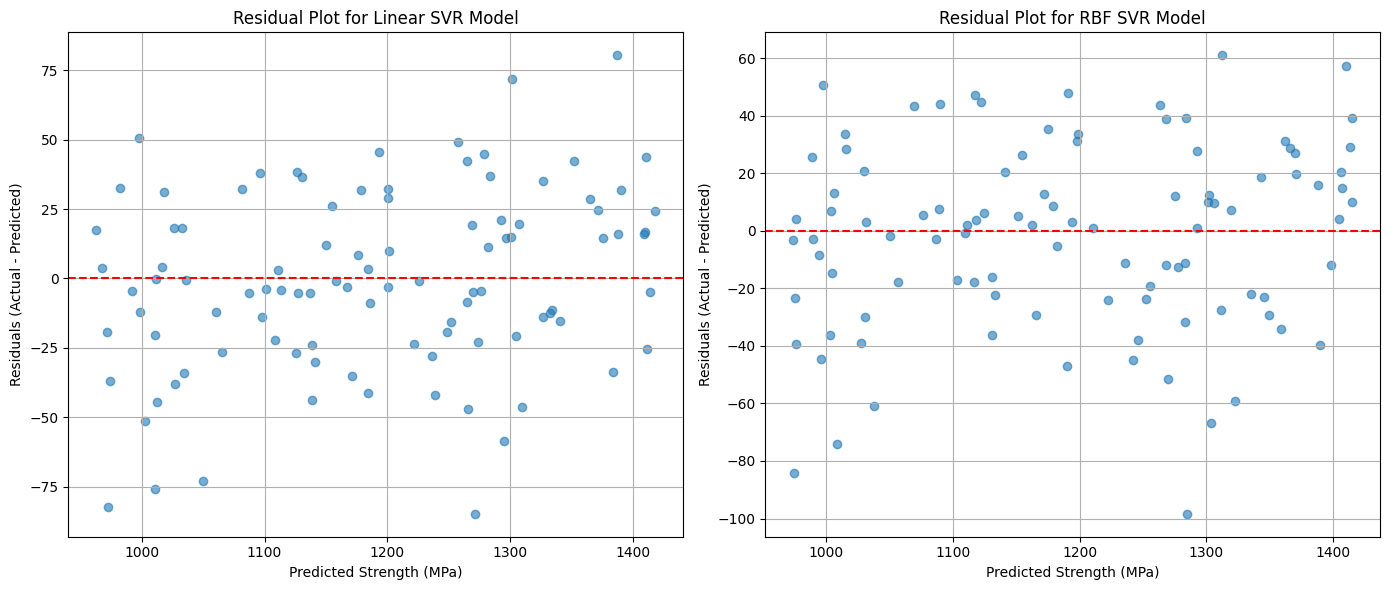

In [22]:
residuals_linear = y_test - y_pred_linear
residuals_rbf = y_test - y_pred_rbf

plt.figure(figsize=(14, 6))

# Residual Plot for Linear SVR
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(y_pred_linear, residuals_linear, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Strength (MPa)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot for Linear SVR Model')
plt.grid(True)

# Residual Plot for RBF SVR
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(y_pred_rbf, residuals_rbf, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Strength (MPa)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot for RBF SVR Model')
plt.grid(True)

plt.tight_layout()
plt.show()

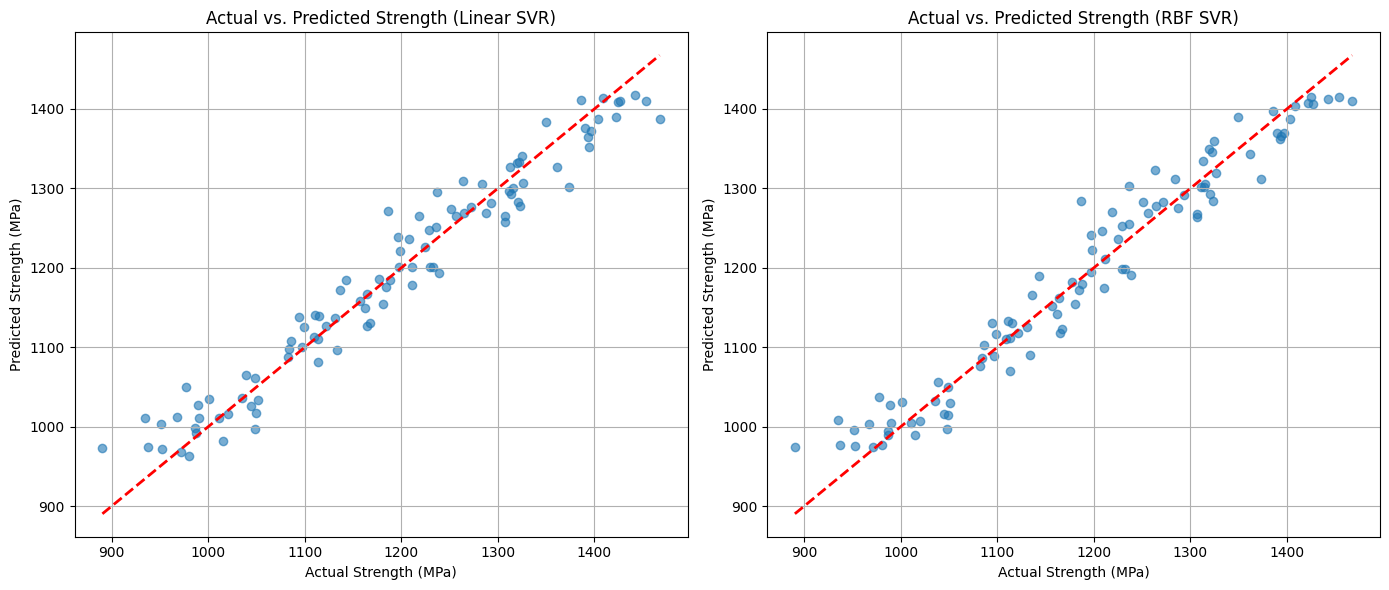

In [23]:
plt.figure(figsize=(14, 6))

# Actual vs. Predicted for Linear SVR
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(y_test, y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Actual vs. Predicted Strength (Linear SVR)')
plt.grid(True)

# Actual vs. Predicted for RBF SVR
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(y_test, y_pred_rbf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Actual vs. Predicted Strength (RBF SVR)')
plt.grid(True)

plt.tight_layout()
plt.show()

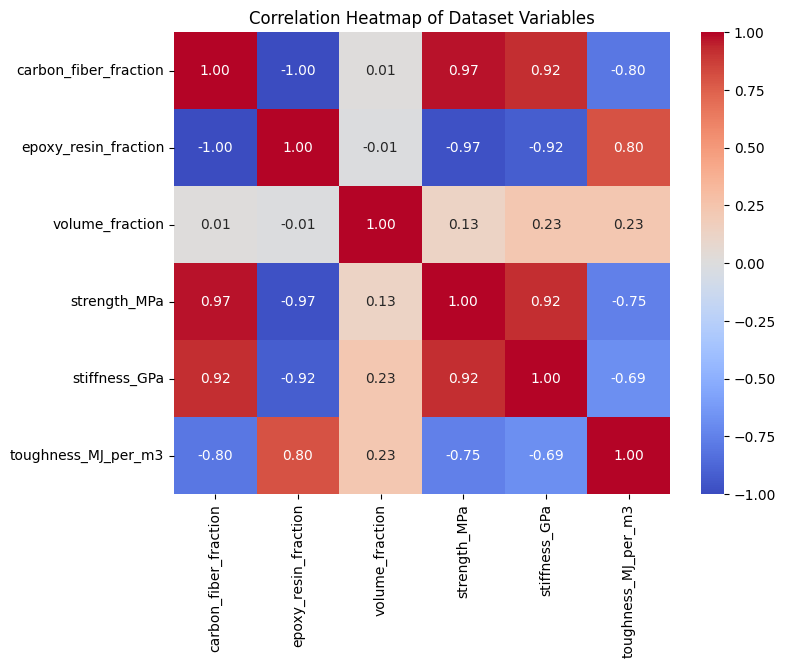

In [24]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Dataset Variables')
plt.show()

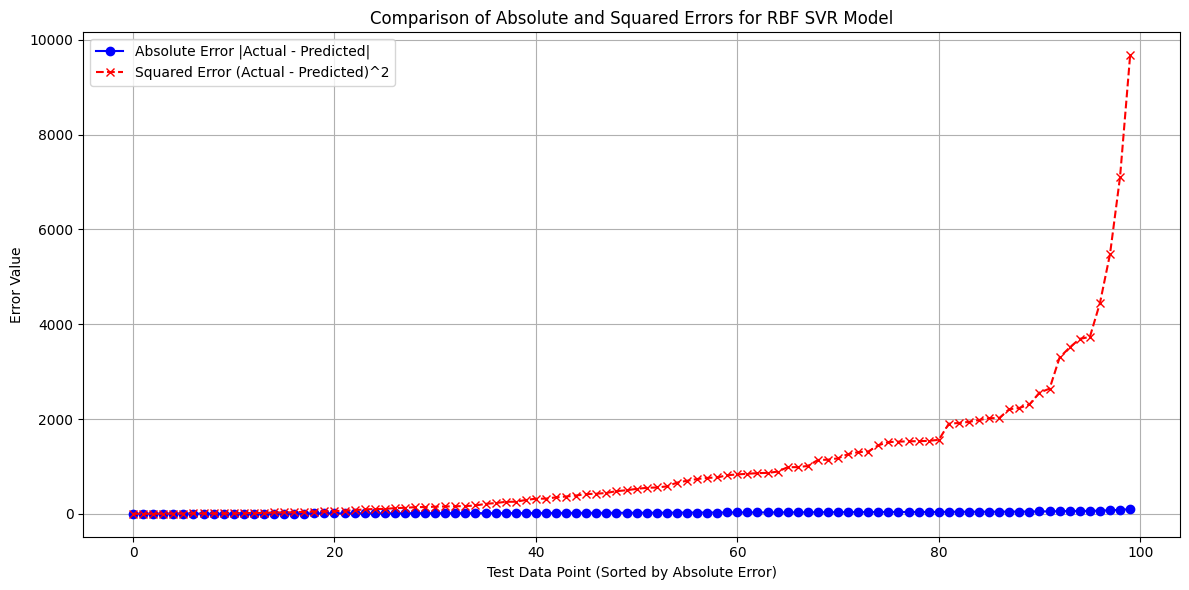

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure residuals_rbf is available, if not, re-calculate
if 'residuals_rbf' not in locals():
    y_pred_rbf = rbf_svr.predict(X_test_scaled)
    residuals_rbf = y_test - y_pred_rbf

abs_errors = np.abs(residuals_rbf)
sq_errors = residuals_rbf**2

# Sort errors by absolute error magnitude to better visualize the amplification
sorted_indices = np.argsort(abs_errors)
sorted_abs_errors = abs_errors.iloc[sorted_indices]
sorted_sq_errors = sq_errors.iloc[sorted_indices]

plt.figure(figsize=(12, 6))

# Plot Absolute Errors
plt.plot(range(len(sorted_abs_errors)), sorted_abs_errors, marker='o', linestyle='-', color='blue', label='Absolute Error |Actual - Predicted|')

# Plot Squared Errors
plt.plot(range(len(sorted_sq_errors)), sorted_sq_errors, marker='x', linestyle='--', color='red', label='Squared Error (Actual - Predicted)^2')

plt.xlabel('Test Data Point (Sorted by Absolute Error)')
plt.ylabel('Error Value')
plt.title('Comparison of Absolute and Squared Errors for RBF SVR Model')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

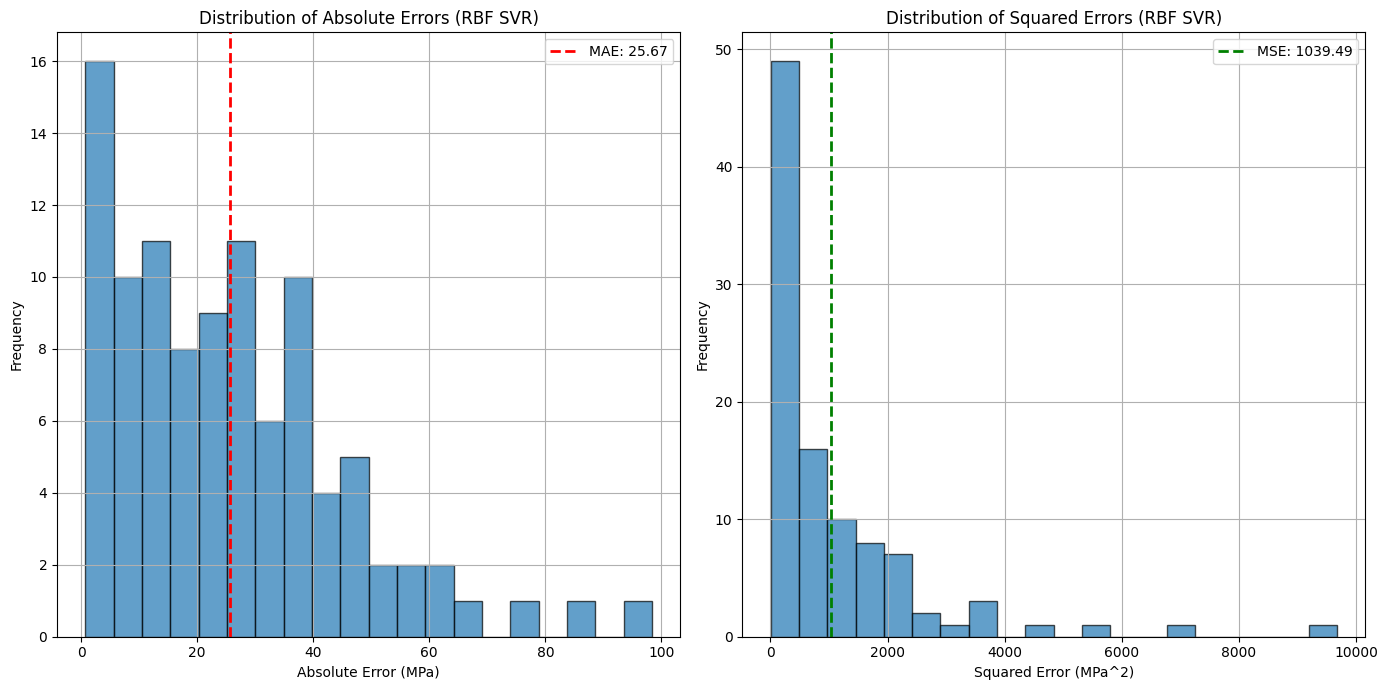

Mean Absolute Error (MAE): 25.67
Root Mean Squared Error (RMSE): 32.24
Mean Squared Error (MSE): 1039.49


In [27]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

# Ensure residuals_rbf is available, if not, re-calculate
if 'residuals_rbf' not in locals():
    y_pred_rbf = rbf_svr.predict(X_test_scaled)
    residuals_rbf = y_test - y_pred_rbf

abs_errors = np.abs(residuals_rbf)
sq_errors = residuals_rbf**2

mae = mean_absolute_error(y_test, y_pred_rbf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rbf))

plt.figure(figsize=(14, 7))

# Histogram of Absolute Errors
plt.subplot(1, 2, 1)
plt.hist(abs_errors, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mae, color='red', linestyle='dashed', linewidth=2, label=f'MAE: {mae:.2f}')
plt.title('Distribution of Absolute Errors (RBF SVR)')
plt.xlabel('Absolute Error (MPa)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

# Histogram of Squared Errors
plt.subplot(1, 2, 2)
plt.hist(sq_errors, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mse_rbf, color='green', linestyle='dashed', linewidth=2, label=f'MSE: {mse_rbf:.2f}')
plt.title('Distribution of Squared Errors (RBF SVR)')
plt.xlabel('Squared Error (MPa^2)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Squared Error (MSE): {mse_rbf:.2f}")
